## Keras 3 - MADE
This code is an implementation of ["Masked AutoEncoder for Density Estimation"](https://arxiv.org/abs/1502.03509) by Germain et al., 2015. The core idea is that you can turn an auto-encoder into an autoregressive density model just by appropriately masking the connections in the MLP, ordering the input dimensions in some way and making sure that all outputs only depend on inputs earlier in the list. Like other autoregressive models (char-rnn, pixel cnns, etc), evaluating the likelihood is very cheap (a single forward pass), but sampling is linear in the number of dimensions.

**This notebook is a keras3 implementation of [code by Andrej karpathy](https://github.com/karpathy/pytorch-made/blob/master/made.py)**

In [1]:
import jax
import jax.numpy as jnp
import keras
from keras import ops
import keras.layers as L
import numpy as np
from functools import partial

In [2]:
print(keras.backend.backend())

jax


## Define MADE model

The Made model needs a masked linear layer to be created followed by the model

### Masked Linear layer 

In [135]:
class MaskedLinear(L.Dense):
    def __init__(self,units,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=None,
        bias_regularizer=None,
        activity_regularizer=None,
        kernel_constraint=None,
        bias_constraint=None,
        lora_rank=None, **kwargs):
        super().__init__(units=units, activation=activation,
                         use_bias=use_bias,
                         kernel_initializer=kernel_initializer,
                         bias_initializer=bias_initializer,
                         kernel_regularizer=kernel_regularizer,
                         bias_regularizer=bias_regularizer,
                         activity_regularizer=activity_regularizer,
                         kernel_constraint=kernel_constraint,
                         bias_constraint=bias_constraint,
                         lora_rank=lora_rank,**kwargs)
        
    def build(self,input_shape):
        super().build(input_shape)
        ## Transpose the shape compared to the kernel matrix for matmult to be correctly applied
        self.mask = self.add_weight(name=f'{self.name}_Mask',shape=self.kernel.shape,
                                   initializer=keras.initializers.ones(),
                                   trainable=False)
    def set_mask(self,mask):
        self.mask.assign(ops.cast(mask,'uint8'))
        
    def call(self,x):
        masked_kernel = ops.multiply(self.kernel,self.mask)
        x = ops.matmul(x,masked_kernel) 
        if self.bias is not None:
            x = ops.add(x, self.bias)
        if self.activation is not None:
            x = self.activation(x)
        return x

### MADE Model
The direct translation from pytorch would be a subclassed model, but I'm taking a shortcut and creating a functional model instead

In [136]:
class MADE:
    def __init__(self,nin, hidden_sizes, nout, num_masks=1, natural_ordering=False):
        """
        nin: integer; number of inputs
        hidden sizes: a list of integers; number of units in hidden layers
        nout: integer; number of outputs, which usually collectively parameterize some kind of 1D distribution
              note: if nout is e.g. 2x larger than nin (perhaps the mean and std), then the first nin
              will be all the means and the second nin will be stds. i.e. output dimensions depend on the
              same input dimensions in "chunks" and should be carefully decoded downstream appropriately.
              the output of running the tests for this file makes this a bit more clear with examples.
        num_masks: can be used to train ensemble over orderings/connections
        natural_ordering: force natural ordering of dimensions, don't use random permutations
        """
        self.nin = nin
        self.nout = nout
        self.hidden_sizes = hidden_sizes
        assert self.nout % self.nin == 0, "nout must be integer multiple of nin"
        ## Create Model
        self.model = self.create_model()
        # seeds for orders/connectivities of the model ensemble
        self.natural_ordering = natural_ordering
        self.num_masks = num_masks
        self.seed = 0 # for cycling through num_masks orderings

        self.m = {}
        self.masks = self.update_masks() # builds the initial self.m connectivity
        self.apply_masks(self.masks)
        
    def create_model(self):
        model = keras.Sequential()
        model.add(L.Input(shape=(self.nin,)))
        for hd in self.hidden_sizes:
            model.add(MaskedLinear(units=hd,activation="relu"))
        model.add(MaskedLinear(units=self.nout, activation="linear"))
        return model
    
    def update_masks(self):
        # only a single seed, skip for efficiency
        if self.m and self.num_masks==1:
            return

        l_hidden = len(self.hidden_sizes)
        # fetch the next seed and construct a random stream
        rng = np.random.RandomState(self.seed)
        self.seed = (self.seed + 1) % self.num_masks

        # sample the order of the inputs and the connectivity of all neurons
        self.m[-1] = np.arange(self.nin) if self.natural_ordering else rng.permutation(self.nin)

        for l in range(l_hidden):
            self.m[l] = rng.randint(self.m[l-1].min(), self.nin-1, size=self.hidden_sizes[l])
            
        # construct the mask matrices
        masks = [self.m[l-1][:,None] <= self.m[l][None,:] for l in range(l_hidden)]
        masks.append(self.m[l_hidden-1][:,None] < self.m[-1][None,:])

        # handle the case where nout = nin * k, for integer k > 1
        if self.nout > self.nin:
            k = int(self.nout / self.nin)
            # replicate the mask across the other outputs
            masks[-1] = np.concatenate([masks[-1]]*k, axis=1)
        return masks
        
    def apply_masks(self,masks):
        # set the masks in all MaskedLinear layers
        layers = [l for l in self.model.layers if isinstance(l, MaskedLinear)]
        for l,m in zip(layers, masks):
            l.set_mask(m)
        
    def summary(self):
        self.model.summary()

### Testing Autoregressive Property 

We check if the masking is correctly creating independence between variables by inspecting the gradients of the outputs w.r.t the inputs. 

**JAX housekeeping**

JAX needs definitions for stateless versions of the forward pass to be usable. We define the `JAXTrainer` helper class to wrap the model inference

In [139]:
class JAXTrainer:
    def __init__(self,model):
        def compute_loss_and_updates(trainable_variables, non_trainable_variables, x, k):
            y_pred, non_trainable_variables = model.stateless_call(
                trainable_variables, non_trainable_variables, x, training=True
            )
            loss = y_pred[0, k]
            return loss, non_trainable_variables
            
        ## Get derivates w.rt. the weights as well as the input.
        grad_fn = jax.value_and_grad(compute_loss_and_updates,argnums=(0,2), has_aux=True)
        
        @jax.jit
        def step_fn(state, x, k):
            trainable_variables, non_trainable_variables = state
            (loss, non_trainable_variables), (weight_grads,input_grads) = grad_fn(
                trainable_variables, non_trainable_variables, x, k
            )
            return loss, (
                trainable_variables,
                non_trainable_variables),weight_grads,input_grads
        # 4. Save the compiled step function to the instance
        self._compiled_train_step = step_fn
        
    def train_step(self, state, x, k):
        return self._compiled_train_step(state, x, k)

In [140]:
nin, hiddens, nout, natural_ordering = D, [200], D, False

In [141]:
# run a quick and dirty test for the autoregressive property
D = 10
rng = np.random.RandomState(14)
x = jnp.array((rng.rand(1, D) > 0.5).astype(np.float32))

configs = [
    (D, [], D, False),                 # test various hidden sizes
    (D, [200], D, False),
    (D, [200, 220], D, False),
    (D, [200, 220, 230], D, False),
    (D, [200, 220], D, True),          # natural ordering test
    (D, [200, 220], 2*D, True),       # test nout > nin
    (D, [200, 220], 3*D, False),       # test nout > nin
]

for nin, hiddens, nout, natural_ordering in configs:
    
    print("checking nin %d, hiddens %s, nout %d, natural %s" % 
         (nin, hiddens, nout, natural_ordering))
    made = MADE(nin, hiddens, nout, natural_ordering=natural_ordering)
    trainable_variables = [v.value for v in made.model.trainable_variables]
    non_trainable_variables = [v.value for v in made.model.non_trainable_variables]
    state = trainable_variables, non_trainable_variables
    jax_trainer = JAXTrainer(made.model)
    
    # run backpropagation for each dimension to compute what other
    # dimensions it depends on.
    res = []
    for k in range(nout):
        loss, state ,  weight_grads, input_grads = jax_trainer.train_step(state,x, k)
        
        depends = (input_grads != 0).astype(np.uint8)
        depends_ix = jnp.where(depends)[1].tolist()
        isok = k % nin not in depends_ix
        
        res.append((len(depends_ix), k, depends_ix, isok))
    
    # pretty print the dependencies
    res.sort()
    for nl, k, ix, isok in res:
        print("output %2d depends on inputs: %30s : %s" % (k, ix, "OK" if isok else "NOTOK"))

checking nin 10, hiddens [], nout 10, natural False
output  8 depends on inputs:                             [] : OK
output  4 depends on inputs:                            [8] : OK
output  0 depends on inputs:                         [4, 8] : OK
output  7 depends on inputs:                      [0, 4, 8] : OK
output  2 depends on inputs:                   [0, 4, 7, 8] : OK
output  9 depends on inputs:                [0, 2, 4, 7, 8] : OK
output  5 depends on inputs:             [0, 2, 4, 7, 8, 9] : OK
output  6 depends on inputs:          [0, 2, 4, 5, 7, 8, 9] : OK
output  1 depends on inputs:       [0, 2, 4, 5, 6, 7, 8, 9] : OK
output  3 depends on inputs:    [0, 1, 2, 4, 5, 6, 7, 8, 9] : OK
checking nin 10, hiddens [200], nout 10, natural False
output  8 depends on inputs:                             [] : OK
output  4 depends on inputs:                            [8] : OK
output  0 depends on inputs:                         [4, 8] : OK
output  7 depends on inputs:                    

## Training the model on MNIST

In [168]:
import matplotlib.pyplot as plt

### Dataset Creation
The first step is creating the dataset

In [143]:
# reproducibility is good
np.random.seed(42)

In [192]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

Convert numpy arrarys to JAX arrays which are loaded to GPU. We don't need the labels so we only keep the train and test inputs

In [193]:
x_train = jnp.array(x_train)
x_test = jnp.array(x_test)
print(x_train.device,",",x_test.device)

cuda:0 , cuda:0


## Data pre-processing
For MADE we need to binarize MNIST

In [194]:
def binarize_data(x):
    x = ops.divide(x,255.) - 0.125 # Shifting the threshold
    x = ops.round(x)
    return x

In [199]:
def plot_grid(images):
    fig, axes = plt.subplots(5, 5, figsize=(5, 5))
    
    # 3. Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    for i in range(25):
        axes[i].imshow(images[i], cmap='gray')
        axes[i].set_title(f"Img {i+1}", fontsize=8)
        axes[i].axis('off')  # Hide tick marks for a cleaner look
    
    # 4. Adjust layout to prevent overlapping titles
    plt.tight_layout()
    plt.show()

In [195]:
x_train_bin = binarize_data(x_train)
x_test_bin = binarize_data(x_test)

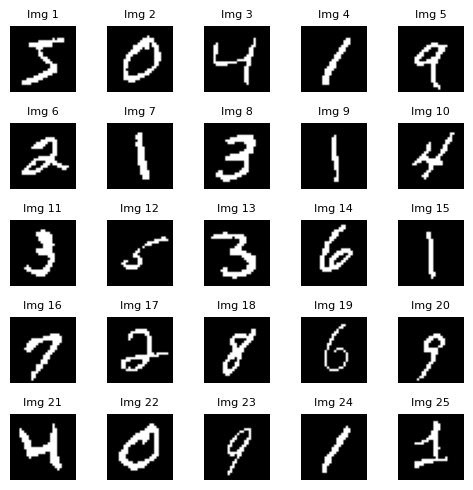

In [200]:
plot_grid(x_train_bin)

Since we are using dense models, we need to flatten the data for training

In [219]:
xtr = ops.reshape(x_train_bin,(x_train_bin.shape[0],ops.prod(x_train_bin.shape[1:])))
xte = ops.reshape(x_test_bin,(x_test_bin.shape[0],ops.prod(x_test_bin.shape[1:])))

In [220]:
print(xtr.shape,xte.shape)

(60000, 784) (10000, 784)


### Creating MADE Model

In [212]:
# Define the hidden layers
hidden_list = [500]

Create the actual model

In [221]:
made = MADE(x_train_bin.shape[1], hidden_list, x_train_bin.shape[1], num_masks=1)
model = made.model

In [222]:
made.summary()

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masked_linear_99 (MaskedLinear) │ (None, 500)            │        28,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masked_linear_100               │ (None, 28)             │        28,028 │
│ (MaskedLinear)                  │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,528 (220.81 KB)

 Trainable params: 28,528 (111.44 KB)

 Non-trainable params: 28,000 (109.38 KB)

### Setting up the training tools

In [223]:
class StepLR:
    def __init__(self,step_size,gamma):
        self.step_size = step_size
        self.gamma = gamma
    def scheduler(epoch, lr):
        if epoch % self.step_size == 0:
            return lr*self.gamma
        else:
            return lr

In [224]:
epochs = 100
opt = keras.optimizers.Adam(learning_rate=0.03,weight_decay=1e-4)
schedule = StepLR(step_size=45,gamma=0.1)
scheduler = keras.callbacks.LearningRateScheduler(schedule.scheduler)

In [228]:
lossfn = keras.losses.BinaryCrossentropy(from_logits=True)

In [227]:
model.compile(optimizer=opt,loss=loss)

### Creating the Train Step

In [238]:
class JAXTrainer:
    def __init__(self,made,x_train,x_test, 
                 lossfn, opt:keras.Optimizer,
                 batch_size=100):
        self.made = made
        self.model = self.made.model
        self.opt = opt
        trainable_variables = [v.value for v in self.model.trainable_variables]
        non_trainable_variables = [v.value for v in self.model.non_trainable_variables]
        opt_variables = [v.value for v in self.opt.variables]
        self.state = state = trainable_variables, non_trainable_variables, opt_variables
        
        self.lossfn = lossfn
        self.nsamples = nsamples
        self.resample_every = 20
        self.x_train = x_train
        self.x_test = x_test
        self.batch_size = batch_size
        # Generate JAX Compiled Function
        self.get_training_fn()

    def get_training_fn(self, x):
        """ Return JAX.jit version of optimization function"""
        model = self.model
        made = self.made
        lossfn = self.lossfn
        nsamples = self.nsamples
        resample_every = self.resample_every 
        N,D = self.x_train.shape
        B = self.batch_size
        opt = self.opt
        
        def compute_loss_and_updates(trainable_variables, non_trainable_variables, x):
            xbhat = ops.zeros_like(x)
            for s in range(nsamples):
                if step % resample_every == 0:
                    made.update_masks()
                x_out, non_trainable_variables = model.stateless_call(
                    trainable_variables, non_trainable_variables, x, training=True)
                xbhat += x_out

            loss = lossfn(xbhat, x) / B
            return loss, non_trainable_variables
            
        ## Get derivates w.rt. the weights as well as the input.
        grad_fn = jax.value_and_grad(compute_loss_and_updates, has_aux=True)
        
        @jax.jit
        def step_fn(state, x):
            # Compute forward value and grad
            trainable_variables, non_trainable_variables, optimizer_variables = state
            (loss, non_trainable_variables), grads = grad_fn(
                trainable_variables, non_trainable_variables, x, y
            )
            ## Apply Grads to Optimizer
            trainable_variables, optimizer_variables = opt.stateless_apply(
                optimizer_variables, grads, trainable_variables
            )
            # Return updated state
            return loss, (
                trainable_variables,
                non_trainable_variables,
                optimizer_variables,
            )
        # 4. Save the compiled step function to the instance
        self._compiled_train_step = step_fn

        ## TESTING FUNCTIONS
        def compute_loss(trainable_variables, non_trainable_variables, x):
            xbhat = ops.zeros_like(x)
            for s in range(nsamples):
                made.update_masks()
                x_out, non_trainable_variables = model.stateless_call(
                    trainable_variables, non_trainable_variables, x, training=True)
                xbhat += x_out

            loss = lossfn(xbhat, x) / B
            return loss, non_trainable_variables

    def test_step(self,upto=None):
        nsteps = N//B if upto is None else min(N//B, upto)
        nsamples = self.nsamples
        N,D = self.x_test.shape
        state = self.state
        nsteps = N//B if upto is None else min(N//B, upto)
        for step in range(nsteps):
            xb = self.x_test[step*self.batch_size:step*self.batch_size+self.batch_size] # Get nextbatch
            
                
    def training_steps(self, split, upto=None):
        N,D = self.x_train.shape
        nsteps = N//self.batch_size
        state = self.state
        lossfs = []
        for step in range(nsteps):
            xb = self.x_train[step*self.batch_size:step*self.batch_size+self.batch_size] # Get nextbatch
            loss, state = self._compiled_train_step(state, x, k)
            lossfs.append(loss.value)
            if nsteps % 50 == 0:
                print(f"Training loss (for 1 batch) at step {step}: {float(loss):.4f}")
                print(f"Seen so far: {(step + 1) * batch_size} samples")

IndentationError: expected an indented block after 'for' statement on line 73 (2982454744.py, line 74)

In [225]:
def run_epoch(split, upto=None):
    torch.set_grad_enabled(split=='train') # enable/disable grad for efficiency of forwarding test batches
    model.train() if split == 'train' else model.eval()
    nsamples = 1 if split == 'train' else args.samples
    x = xtr if split == 'train' else xte
    N,D = x.size()
    B = 100 # batch size
    nsteps = N//B if upto is None else min(N//B, upto)
    lossfs = []
    for step in range(nsteps):
        
        # fetch the next batch of data
        xb = Variable(x[step*B:step*B+B])
        
        # get the logits, potentially run the same batch a number of times, resampling each time
        xbhat = torch.zeros_like(xb)
        for s in range(nsamples):
            # perform order/connectivity-agnostic training by resampling the masks
            if step % args.resample_every == 0 or split == 'test': # if in test, cycle masks every time
                model.update_masks()
            # forward the model
            xbhat += model(xb)
        xbhat /= nsamples
        
        # evaluate the binary cross entropy loss
        loss = F.binary_cross_entropy_with_logits(xbhat, xb, size_average=False) / B
        lossf = loss.data.item()
        lossfs.append(lossf)
        
        # backward/update
        if split == 'train':
            opt.zero_grad()
            loss.backward()
            opt.step()
        
    print("%s epoch average loss: %f" % (split, np.mean(lossfs)))